#  Imports and Load Data

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw_listings.csv')

In [218]:
import pandas as pd
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Load the environment variables
load_dotenv()

# 1. Connect to Supabase
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

# 2. Pull ALL cars from the database
print("Downloading all data from Supabase...")
df = pd.read_sql("SELECT * FROM cars", engine)

# 3. Fill the missing condition/title_status/trim with 'unspecified'
df['condition'] = df['condition'].fillna('unspecified')
df['title_status'] = df['title_status'].fillna('unspecified')
df['trim'] = df['trim'].fillna('unspecified')

# If the LLM hit an error, treat it as unspecified too
df['trim'] = df['trim'].replace('Error', 'unspecified')

print(f"Downloaded {len(df)} total cars!")
df.head()

Downloaded 14430 total cars!


,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
0,2021 Audi I Q5 Plug-In Hybrid,https://www.craigslist.org/view/d/orinda-2021-...,28800,67000.0,lafayette,Audi,2021,Q5,5,23685.80,-5114.207031,excellent,clean,Base
1,2005 Volvo S40 – 117K Miles,https://www.craigslist.org/view/d/oakland-2005...,3900,118000.0,alameda,Volvo,2005,S40,21,5253.68,1353.682617,good,salvage,Base
2,2018 Infiniti G50 Luxury,https://www.craigslist.org/view/d/fairfield-20...,8900,110000.0,fairfield,Infiniti,2018,G50,8,11903.50,3003.505859,unspecified,unspecified,Luxury
3,2015 Mercedes-Benz C250 Sport,https://www.craigslist.org/view/d/roswell-2015...,9900,82000.0,roswell,Mercedes-Benz,2015,C250,11,13997.60,4097.647461,unspecified,clean,Sport
4,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi,2014,A7,12,7280.32,-1619.683105,unspecified,unspecified,Prestige Quattro S Line


In [219]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
3559,1990 Jeep Wrangler Yj-4 Cylinder,https://www.craigslist.org/view/d/caliente-199...,5500,128000.0,san fernando valley,Jeep,1990,Wrangler,36,8037.50,2537.496094,unspecified,unspecified,unspecified
13821,2015 Acura Rdx Awd W/Tech Package,https://www.craigslist.org/view/d/lakewood-201...,12100,123000.0,lakewood,Acura,2015,Rdx,11,9767.15,-2332.847656,unspecified,unspecified,unspecified
7920,2014 Lexus Ls 460,https://www.craigslist.org/view/d/fort-lauderd...,18999,75000.0,davie,Lexus,2014,Ls,12,21489.50,2490.468750,unspecified,unspecified,unspecified
3511,"2016 Honda Crv Awd Touring , Under My Name , C...",https://www.craigslist.org/view/d/los-angeles-...,13300,102000.0,los angeles,Honda,2016,Crv,10,11390.70,-1909.341797,unspecified,unspecified,unspecified
6577,2007 Chevrolet Silverado 4X4,https://www.craigslist.org/view/d/red-oak-2007...,15000,155000.0,red oak tx,Chevrolet,2007,Silverado,19,9781.87,-5218.133789,unspecified,rebuilt,unspecified
13834,1969 Gmc C10 - 383 Stroker,https://www.craigslist.org/view/d/lacey-1969-g...,13750,123000.0,lacey,Gmc,1969,Other,57,17628.60,3878.632812,unspecified,unspecified,unspecified
4943,Ford F-250 1996 7.3L,https://www.craigslist.org/view/d/stanwood-for...,15000,264000.0,stanwood,Ford,1996,F250,30,9765.09,-5234.907227,excellent,clean,unspecified
3419,2019 Mercedes Benz Sprinter Ceo Executive Limo...,https://www.craigslist.org/view/d/los-angeles-...,64995,43000.0,los angeles,Mercedes,2019,Sprinter,7,54592.50,-10402.531250,unspecified,unspecified,unspecified
5236,2010 Land Rover Range Rover Sport Supercharged,https://www.craigslist.org/view/d/milton-2010-...,13500,69000.0,milton,Land Rover,2010,Range Rover,16,12536.10,-963.886719,unspecified,unspecified,unspecified
8497,2020 Audi S7 Premium Plus – Original Owner – C...,https://www.craigslist.org/view/d/marietta-202...,27500,66000.0,city of atlanta,Audi,2020,Other,6,16958.10,-10541.929688,unspecified,unspecified,unspecified


In [220]:
df.describe()

,price,mileage,year,age,predicted_price,difference
count,14430.000000,14430.000000,14430.000000,14430.000000,14430.000000,14430.000000
mean,10778.360776,126652.156826,2008.561331,17.438669,10518.578062,-259.782671
std,10702.364366,59843.587057,12.778909,12.778909,8193.682570,5943.769222
min,800.000000,100.000000,1922.000000,-1.000000,-2198.350000,-95546.713379
25%,4300.000000,86000.000000,2005.000000,10.000000,5157.720000,-1437.090942
50%,7500.000000,126000.000000,2012.000000,14.000000,7735.635000,374.741211
75%,13250.000000,167000.000000,2016.000000,21.000000,13108.900000,1934.621643
max,100000.000000,300000.000000,2027.000000,104.000000,90188.800000,34732.460938


# EDA & Data Cleaning

### Feature Cleaning: Location

In [221]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [222]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
4758,2012 Mazda 3 I Touring Sedan,https://www.craigslist.org/view/d/kent-2012-ma...,7500,141000.0,kent,Mazda,2012,2,14,5025.30,-2474.697754,unspecified,unspecified,unspecified
9598,2020 Ford Expedition Max Limited,https://www.craigslist.org/view/d/phoenix-2020...,19800,81000.0,west phoenix,Ford,2020,Expedition,6,17639.40,-2160.628906,good,rebuilt,unspecified
10079,Adorable And Classy 2002 Kia Optima Ls,https://www.craigslist.org/view/d/apache-junct...,2300,184000.0,apache junction,Kia,2002,Optima,24,2563.70,263.696777,unspecified,unspecified,unspecified
14157,2002 Honda Passport,https://www.craigslist.org/view/d/alpharetta-2...,3000,172000.0,alpharetta,Honda,2002,Passport,24,4106.06,1106.064453,unspecified,unspecified,unspecified
4122,2025 Honda Accord Lx 40K Miles,https://www.craigslist.org/view/d/baldwin-2025...,22500,40000.0,baldwin,Honda,2025,Accord,1,23037.40,537.449219,unspecified,unspecified,unspecified
5408,1997 Bmw 320I E36 Jdm Right-Hand Drive Sedan –...,https://www.craigslist.org/view/d/bellevue-199...,12900,35000.0,bellevue,Bmw,1997,Other,29,14026.10,1126.134766,unspecified,unspecified,unspecified
3350,2011 Audi A5 2.0T Premium Cabriolet 2D,https://www.craigslist.org/view/d/north-hollyw...,9300,76000.0,san fernando valley,Audi,2011,A5,15,9774.52,474.517578,excellent,clean,unspecified
1016,2016 Toyota Prius Four Touring – Newly Replace...,https://www.craigslist.org/view/d/hayward-2016...,13750,157000.0,hayward,Toyota,2016,Prius,10,9755.59,-3994.411133,unspecified,unspecified,Four Touring
51,2014 Ford F-150 F150 Super Cab - 100K Miles,https://www.craigslist.org/view/d/phoenix-2014...,13900,100000.0,phoenix,Ford,2014,F-150,12,12477.80,-1422.217773,unspecified,clean,Super Cab
11886,"1999 Chevrolet K2500, 3/4 Ton, 4Wd, Crew Cab, ...",https://www.craigslist.org/view/d/phoenix-1999...,6500,250000.0,cave creek,Chevrolet,1999,Other,27,6761.76,261.761230,good,clean,unspecified


### Univariate Analysis & Outliers

In [223]:
print(df[['price', 'mileage']].describe())

               price        mileage
count   14430.000000   14430.000000
mean    10778.360776  126652.156826
std     10702.364366   59843.587057
min       800.000000     100.000000
25%      4300.000000   86000.000000
50%      7500.000000  126000.000000
75%     13250.000000  167000.000000
max    100000.000000  300000.000000


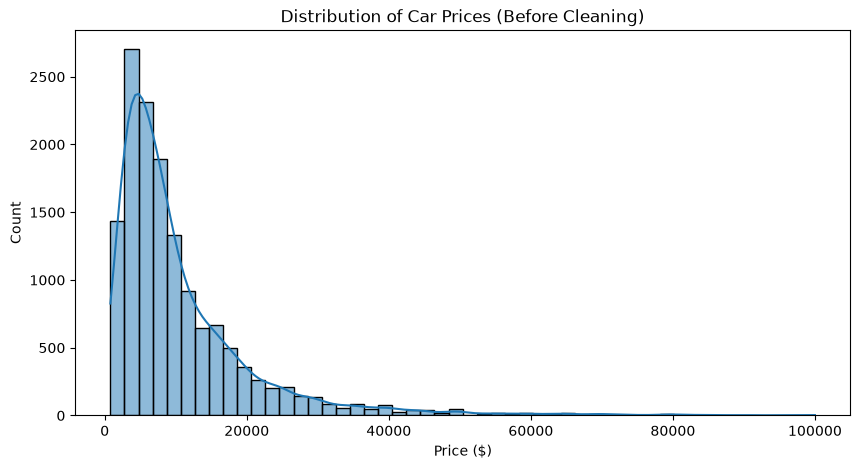

In [224]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

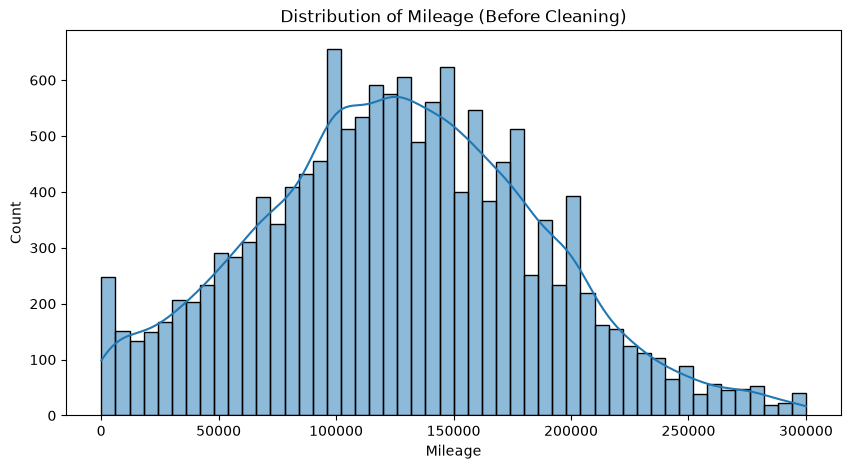

In [225]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [226]:
# 1. Define the realistic bounds for vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# 2. Filter the DataFrame
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE)
].copy()

# Drop any remaining rows where mileage or price might be NaN
df_clean = df_clean.dropna(subset=['price', 'mileage'])

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_clean)}")

# New mathematical summary
print(df_clean[['price', 'mileage']].describe())

Rows before trimming: 14430
Rows after trimming: 14430
               price        mileage
count   14430.000000   14430.000000
mean    10778.360776  126652.156826
std     10702.364366   59843.587057
min       800.000000     100.000000
25%      4300.000000   86000.000000
50%      7500.000000  126000.000000
75%     13250.000000  167000.000000
max    100000.000000  300000.000000


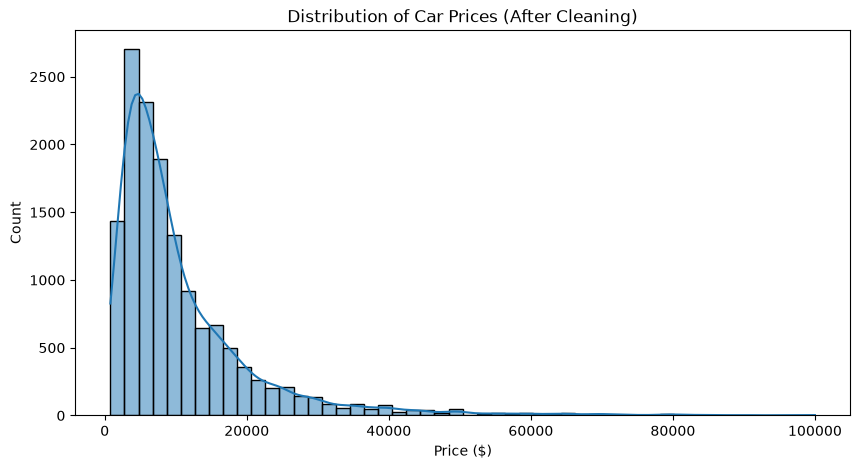

In [227]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

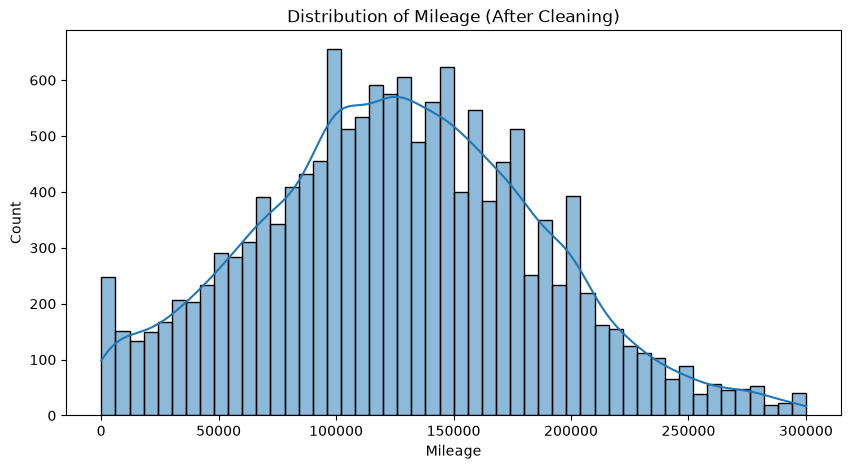

In [228]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [229]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
0,2021 Audi I Q5 Plug-In Hybrid,https://www.craigslist.org/view/d/orinda-2021-...,28800,67000.0,lafayette,Audi,2021,Q5,5,23685.80,-5114.207031,excellent,clean,Base
1,2005 Volvo S40 – 117K Miles,https://www.craigslist.org/view/d/oakland-2005...,3900,118000.0,alameda,Volvo,2005,S40,21,5253.68,1353.682617,good,salvage,Base
2,2018 Infiniti G50 Luxury,https://www.craigslist.org/view/d/fairfield-20...,8900,110000.0,fairfield,Infiniti,2018,G50,8,11903.50,3003.505859,unspecified,unspecified,Luxury
3,2015 Mercedes-Benz C250 Sport,https://www.craigslist.org/view/d/roswell-2015...,9900,82000.0,roswell,Mercedes-Benz,2015,C250,11,13997.60,4097.647461,unspecified,clean,Sport
4,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi,2014,A7,12,7280.32,-1619.683105,unspecified,unspecified,Prestige Quattro S Line
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14425,1993 Volvo 240 Wagon,https://www.craigslist.org/view/d/santa-monica...,14500,225000.0,santa monica,Volvo,1993,Other,33,3542.62,-10957.381348,excellent,clean,unspecified
14426,1987 Chevrolet 5.7L V8 Automatic Transmission,https://www.craigslist.org/view/d/santa-clarit...,7400,129000.0,santa clarita,Chevrolet,1987,Other,39,6759.08,-640.916016,good,clean,unspecified
14427,Gmc Yukon 2013 For Sale,https://www.craigslist.org/view/d/sanger-gmc-y...,8000,184000.0,north dfw,Gmc,2013,Yukon,13,6717.48,-1282.520508,good,clean,unspecified
14428,"2023 Ford F650 Super Duty Crew Cab - 25,364 Mi",https://www.craigslist.org/view/d/san-rafael-2...,79950,25000.0,san rafael,Ford,2023,Other,3,36260.40,-43689.644531,good,clean,unspecified


In [230]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                                                name  year  age
0                      2021 Audi I Q5 Plug-In Hybrid  2021    5
1                        2005 Volvo S40 – 117K Miles  2005   21
2                           2018 Infiniti G50 Luxury  2018    8
3                      2015 Mercedes-Benz C250 Sport  2015   11
4  2014 Audi A7 Prestige Quattro S Line | 3.0T Su...  2014   12


In [231]:
# Drop rows missing the core LLM-enriched features
df_clean = df_clean.dropna(subset=['price', 'mileage', 'year', 'make', 'model', 'trim'])
print(f"Rows after final cleaning: {len(df_clean)}")

Rows after final cleaning: 14430


In [232]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [233]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [234]:
# 1. Define Features (X) and Target (y) and perform train_test_split

X = df_clean[['age', 'make', 'model', 'trim', 'mileage', 'location', 'condition', 'title_status']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [235]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ADDED 'trim' here!
X_train_encoded = ohe.fit_transform(X_train[['make', 'model', 'trim', 'location', 'condition', 'title_status']])
X_test_encoded = ohe.transform(X_test[['make', 'model', 'trim', 'location', 'condition', 'title_status']])

# Put the encoded arrays back into DataFrames so they have column names
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(), index=X_test.index)

# Drop the original text columns, keep only numbers (age, mileage)
# ADDED 'trim' here!
X_train_num = X_train.drop(columns=['make', 'model', 'trim', 'location', 'condition', 'title_status'])
X_test_num = X_test.drop(columns=['make', 'model', 'trim', 'location', 'condition', 'title_status'])

# Combine the numerical columns and encoded columns together
X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)

print(f"Training data shape: {X_train_final.shape}")
print(f"Testing data shape: {X_test_final.shape}")

Training data shape: (11544, 2709)
Testing data shape: (2886, 2709)


## Train the Model

In [236]:
# Diagnostic check: What columns is the model actually seeing?
print("Columns being fed to the model:")
print(X_train_final.columns.tolist())

print("\nFirst 3 rows of training data:")
X_train_final.head(3)

Columns being fed to the model:
['age', 'mileage', 'make_Acura', 'make_Amc', 'make_Audi', 'make_Bentley', 'make_Bmw', 'make_Buick', 'make_Cadillac', 'make_Chevrolet', 'make_Chevy', 'make_Chrysler', 'make_Dodge', 'make_Ford', 'make_Gmc', 'make_Honda', 'make_Hyundai', 'make_Infiniti', 'make_Jaguar', 'make_Jeep', 'make_Kia', 'make_Land Rover', 'make_Lexus', 'make_Mazda', 'make_Mercedes', 'make_Mercedes Benz', 'make_Mercedes Freightliner', 'make_Mercedes-Benz', 'make_Mini', 'make_Mitsubishi', 'make_Nissan', 'make_Pontiac', 'make_Porsche', 'make_Ram', 'make_Rambler', 'make_Rover', 'make_Saturn', 'make_Subaru', 'make_Tesla', 'make_Toyota', 'make_Volkswagen', 'make_Volvo', 'make_Vw', 'model_1500', 'model_1500 Classic', 'model_1962', 'model_2', 'model_2 Door Sedan', 'model_2002', 'model_228I', 'model_2500', 'model_250Sl', 'model_280Sel', 'model_3', 'model_3 Series', 'model_300', 'model_300E', 'model_320I', 'model_323Ci', 'model_325 Ci', 'model_325I', 'model_328', 'model_328I', 'model_330Ci', '

,age,mileage,make_Acura,make_Amc,make_Audi,make_Bentley,make_Bmw,make_Buick,make_Cadillac,make_Chevrolet,...,condition_new,condition_salvage,condition_unspecified,title_status_clean,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,title_status_unspecified
13238,27,124000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12742,28,300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4851,5,44000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [237]:
# Tuned XGBoost Model
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8,     # Uses 80% of data per tree to prevent overfitting
    colsample_bytree=0.8, # Uses 80% of features per tree
    random_state=42
)   

# Train the model!
model.fit(X_train_final, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [238]:
# Make predictions on our test set
predictions = model.predict(X_test_final)

# Calculate Mean Absolute Error (MAE) and R-Squared
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Visually compare actual vs predicted for the first 10 cars
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Make': X_test['make'].values[:10],
    'Model': X_test['model'].values[:10],
    'Trim': X_test['trim'].values[:10], 
    'Mileage': X_test['mileage'].values[:10]
})
print("\nSample Predictions vs Actuals:")
print(comparison)

Model Performance:
Mean Absolute Error (MAE): $3,586.01
R-Squared (R2): 0.63

Sample Predictions vs Actuals:
   Actual_Price  Predicted_Price  Age      Make       Model         Trim  \
0         13600            13094   17      Jeep    Wrangler         Base   
1         18000            18651    6      Ford     Transit  unspecified   
2         49995            39753    6     Dodge  Challenger  unspecified   
3         14000            11559   11     Honda      Accord  unspecified   
4          2500             8296   11      Ford       Focus  unspecified   
5         21500            25207    4    Toyota        Rav4  unspecified   
6          9000             6572    9  Chrysler    Pacifica  unspecified   
7          7500             7073    7    Nissan      Altima  unspecified   
8          6000             7555   19    Toyota       Other  unspecified   
9          7900             7370   14       Bmw    7 Series           Li   

    Mileage  
0  116000.0  
1   99000.0  
2   17000.0 

# Export the model using Pickle

In [239]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

print("Model and Encoder saved successfully to the api/ folder!")

Model and Encoder saved successfully to the api/ folder!


In [240]:
# Save the exact column order from the final training dataframe
joblib.dump(X_train_final.columns.tolist(), '../api/model_columns.pkl')
print("Saved model_columns.pkl!")

Saved model_columns.pkl!
